<a href="https://colab.research.google.com/github/Huyphung111/TH_DeepLearning/blob/main/Lab2_TrainM%C3%B4H%C3%ACnhLinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic preprocessing , Linear Regression + Gradient Descent




CELL 1: import các thư viện cần dùng cho xử lý dữ liệu, trực quan hóa, tiền xử lý, đánh giá mô hình, TensorFlow và PyTorch. Đồng thời thiết lập SEED = 42 để kết quả huấn luyện ổn định hơn khi chạy lại.

In [ ]:
# Cell 1: Cài đặt và import thư viện

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
import torch
import torch.nn as nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.figsize"] = (7, 4)


 CELL 2: upload file CSV từ máy tính lên Google Colab, đọc dữ liệu bằng pandas, sau đó hiển thị kích thước dữ liệu và 5 dòng đầu tiên để kiểm tra nhanh.

In [ ]:
# Cell 2: Load dữ liệu trên Google Colab

# Cách 1: Upload file thủ công lên Colab rồi chạy
from google.colab import files
uploaded = files.upload()

# Lấy tên file csv đầu tiên được upload
csv_path = list(uploaded.keys())[0]
df = pd.read_csv(csv_path)

print("Kích thước dữ liệu:", df.shape)
display(df.head())


Saving titanic_disaster.csv to titanic_disaster.csv
Kích thước dữ liệu: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


CELL 3: Kiểm tra cấu trúc dữ liệu ban đầu tên cột, kiểu dữ liệu, số lượng giá trị thiếu và tỷ lệ thiếu của từng cột. Đồng thời kiểm tra phân bố của target Survived để biết số mẫu sống sót và không sống sót.

In [ ]:
# Cell 3: Xem nhanh cấu trúc dữ liệu

print("Thông tin cột:")
display(pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}))

print("\nPhân bố target Survived:")
display(df["Survived"].value_counts().rename(index={0: "Not survived", 1: "Survived"}))


Thông tin cột:


,column,dtype,missing,missing_percent
PassengerId,PassengerId,int64,0,0.00
Survived,Survived,int64,0,0.00
Pclass,Pclass,int64,0,0.00
Name,Name,object,0,0.00
Sex,Sex,object,0,0.00
Age,Age,float64,177,19.87
SibSp,SibSp,int64,0,0.00
Parch,Parch,int64,0,0.00
Ticket,Ticket,object,0,0.00
Fare,Fare,float64,0,0.00



Phân bố target Survived:


,count
Survived,
Not survived,549
Survived,342


CELL 4: Biểu đồ khám phá dữ liệu, tạo các biểu đồ EDA cơ bản để hiểu dữ liệu trước khi train mô hình, gồm phân bố target, tỷ lệ missing values, quan hệ giữa Age, Fare, Sex, Pclass với khả năng sống sót.

/tmp/ipykernel_2766/1576980246.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 2].boxplot([survived_0, survived_1], labels=["0", "1"])
/tmp/ipykernel_2766/1576980246.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([fare_0, fare_1], labels=["0", "1"])


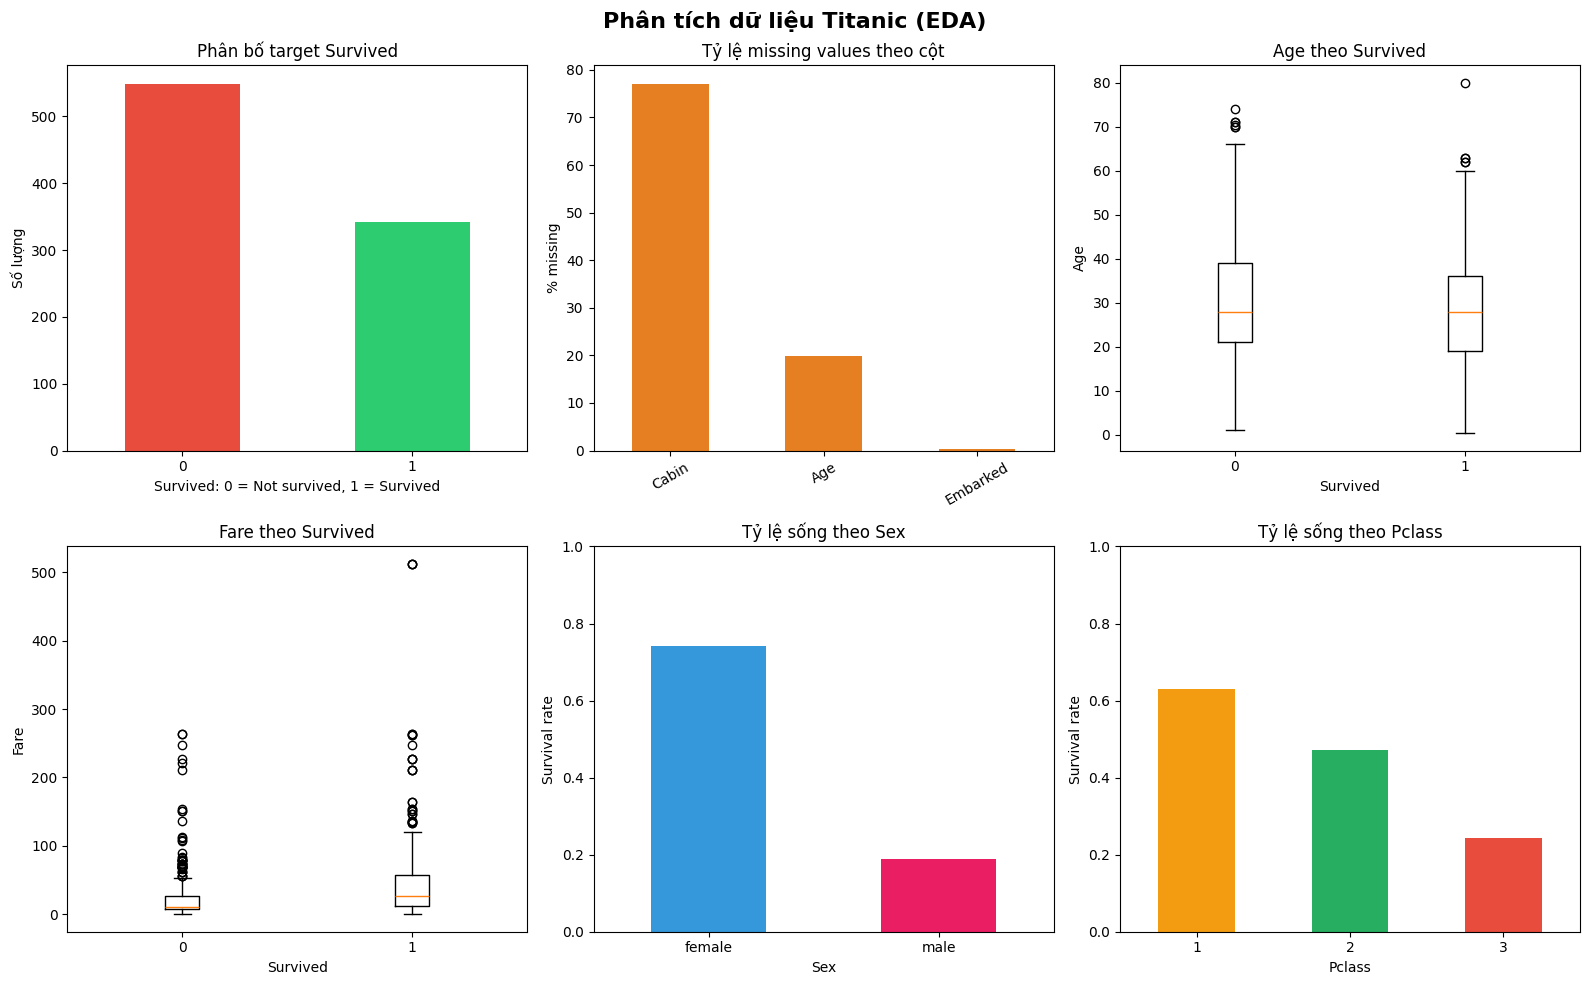

In [19]:
# Cell 4: Biểu đồ EDA cần thiết

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Phân tích dữ liệu Titanic (EDA)', fontsize=16, fontweight='bold')

# 1. Phân bố target
df["Survived"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0], color=['#e74c3c', '#2ecc71'])
axes[0, 0].set_title("Phân bố target Survived")
axes[0, 0].set_xlabel("Survived: 0 = Not survived, 1 = Survived")
axes[0, 0].set_ylabel("Số lượng")
axes[0, 0].tick_params(axis='x', rotation=0)

# 2. Missing values
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)
missing_percent[missing_percent > 0].plot(kind="bar", ax=axes[0, 1], color='#e67e22')
axes[0, 1].set_title("Tỷ lệ missing values theo cột")
axes[0, 1].set_ylabel("% missing")
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. Age theo Survived
survived_0 = df[df["Survived"] == 0]["Age"].dropna()
survived_1 = df[df["Survived"] == 1]["Age"].dropna()
axes[0, 2].boxplot([survived_0, survived_1], labels=["0", "1"])
axes[0, 2].set_title("Age theo Survived")
axes[0, 2].set_xlabel("Survived")
axes[0, 2].set_ylabel("Age")

# 4. Fare theo Survived
fare_0 = df[df["Survived"] == 0]["Fare"].dropna()
fare_1 = df[df["Survived"] == 1]["Fare"].dropna()
axes[1, 0].boxplot([fare_0, fare_1], labels=["0", "1"])
axes[1, 0].set_title("Fare theo Survived")
axes[1, 0].set_xlabel("Survived")
axes[1, 0].set_ylabel("Fare")

# 5. Survival rate theo Sex
sex_rate = df.groupby("Sex")["Survived"].mean()
sex_rate.plot(kind="bar", ax=axes[1, 1], color=['#3498db', '#e91e63'])
axes[1, 1].set_title("Tỷ lệ sống theo Sex")
axes[1, 1].set_ylabel("Survival rate")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis='x', rotation=0)

# 6. Survival rate theo Pclass
pclass_rate = df.groupby("Pclass")["Survived"].mean()
pclass_rate.plot(kind="bar", ax=axes[1, 2], color=['#f39c12', '#27ae60', '#e74c3c'])
axes[1, 2].set_title("Tỷ lệ sống theo Pclass")
axes[1, 2].set_ylabel("Survival rate")
axes[1, 2].set_ylim(0, 1)
axes[1, 2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### CELL 5: Chọn target và input

Target:

`Survived`

Lý do: Đây là cột kết quả cần dự đoán, 0 là không sống sót, 1 là sống sót

Input nên dùng cho mô hình học cơ bản:

- `Pclass`: hạng vé, có liên quan đến điều kiện sinh tồn
- `Sex`: giới tính
- `Age`: tuổi
- `SibSp`: số anh chị em / vợ chồng đi cùng
- `Parch`: số cha mẹ / con cái đi cùng
- `Fare`: giá vé
- `Embarked`: cảng lên tàu

Không dùng:

- `PassengerId`: mã định danh, không mang ý nghĩa dự đoán tốt
- `Name`: nhiều giá trị riêng, cần feature engineering nâng cao
- `Ticket`: nhiều mã riêng, dễ nhiễu với bài cơ bản
- `Cabin`: missing quá nhiều
- `Survived`: không được đưa vào input vì đây là target


In [ ]:
# Cell 5: Chọn input và target

target_col = "Survived"

numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Sex", "Embarked"]

X = df[numeric_features + categorical_features].copy()
y = df[target_col].astype("float32").copy()

print("Input features:", list(X.columns))
print("Target:", target_col)
print("X shape:", X.shape)
print("y shape:", y.shape)


Input features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex', 'Embarked']
Target: Survived
X shape: (891, 7)
y shape: (891,)


 CELL 6: Chọn input và target cho mô hình, chọn Survived làm biến cần dự đoán, còn các cột như Pclass, Age, Fare, Sex, Embarked làm input. Dữ liệu input được lưu vào X, target được lưu vào y.

In [ ]:
# Cell 6: Split dữ liệu trước khi fit bất kỳ preprocessing nào

# Tách test cuối cùng trước
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# Tách validation từ train_val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_val
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (569, 7) (569,)
Validation: (143, 7) (143,)
Test: (179, 7) (179,)


CELL 7: Chia dữ liệu train, validation và test
Chia dữ liệu thành 3 phần. Train dùng để học mô hình, validation dùng để theo dõi trong lúc train, test dùng để đánh giá cuối cùng. Việc split được thực hiện trước preprocessing để tránh data leakage.


In [ ]:
# Cell 7: Tạo preprocessing đúng quy trình

# Numeric:
# - Impute missing bằng median học từ train
# - StandardScaler học mean/std từ train
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical:
# - Impute missing bằng most_frequent học từ train
# - OneHotEncoder học category từ train
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# FIT CHỈ TRÊN TRAIN
X_train_processed = preprocessor.fit_transform(X_train)

# VALIDATION / TEST CHỈ TRANSFORM, KHÔNG FIT LẠI
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed:", X_train_processed.shape)
print("X_val_processed:", X_val_processed.shape)
print("X_test_processed:", X_test_processed.shape)


X_train_processed: (569, 10)
X_val_processed: (143, 10)
X_test_processed: (179, 10)


CELL 8: Tiền xử lý dữ liệu, xử lý dữ liệu số và dữ liệu phân loại. Dữ liệu số được điền missing bằng median và chuẩn hóa bằng StandardScaler. Dữ liệu phân loại được điền missing và mã hóa One-Hot. Bộ xử lý chỉ fit trên train, còn validation và test chỉ transform.

In [ ]:
# Cell 8: Kiểm tra tên feature sau preprocessing

feature_names = preprocessor.get_feature_names_out()
processed_df = pd.DataFrame(X_train_processed, columns=feature_names)

display(processed_df.head())
print("Số feature sau preprocessing:", len(feature_names))


,num__Pclass,num__Age,num__SibSp,num__Parch,num__Fare,cat__Sex_female,cat__Sex_male,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S
0,-0.369051,-0.064840,-0.462989,-0.461079,-0.453710,0.0,1.0,0.0,0.0,1.0
1,-0.369051,0.473657,0.481243,1.860636,-0.071871,0.0,1.0,0.0,0.0,1.0
2,0.830891,-0.987978,0.481243,-0.461079,-0.529985,0.0,1.0,0.0,0.0,1.0
3,-0.369051,-0.526409,-0.462989,-0.461079,-0.398371,0.0,1.0,0.0,0.0,1.0
4,-0.369051,-0.834122,-0.462989,-0.461079,-0.398371,0.0,1.0,0.0,0.0,1.0


Số feature sau preprocessing: 10


## CELL 9: Mô hình 1 Linear Regression bằng TensorFlow

Ta dùng một lớp Dense có 1 output:

`y_pred = w1*x1 + w2*x2 + ... + b`

Loss dùng MSE vì đang thực hành Linear Regression

Accuracy được tính bằng cách ngưỡng hóa:

`y_pred >= 0.5` thì dự đoán là 1, ngược lại là 0


In [ ]:
# Cell 9: Chuẩn bị dữ liệu cho TensorFlow

X_train_tf = X_train_processed.astype("float32")
X_val_tf = X_val_processed.astype("float32")
X_test_tf = X_test_processed.astype("float32")

y_train_tf = y_train.values.astype("float32")
y_val_tf = y_val.values.astype("float32")
y_test_tf = y_test.values.astype("float32")


CELL 10: Kiểm tra dữ liệu sau preprocessing
 Lấy tên các feature sau khi chuẩn hóa và mã hóa, chuyển dữ liệu train đã xử lý thành DataFrame để dễ quan sát. Đồng thời in ra số lượng feature cuối cùng sau preprocessing.

In [ ]:
# Cell 10: Train Linear Regression bằng TensorFlow Gradient Descent

tf_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_tf.shape[1],)),
    tf.keras.layers.Dense(1, activation="linear")
])

tf_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss="mse",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(threshold=0.5, name="accuracy")
    ]
)

tf_history = tf_model.fit(
    X_train_tf,
    y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=100,
    batch_size=32,
    verbose=0
)

print("Train xong TensorFlow")


Train xong TensorFlow


CELL 11: Vẽ loss và accuracy của TensorFlow,
Vẽ biểu đồ loss và accuracy theo từng epoch cho tập train và validation. Biểu đồ giúp theo dõi mô hình học tốt hay bị lệch giữa train và validation.


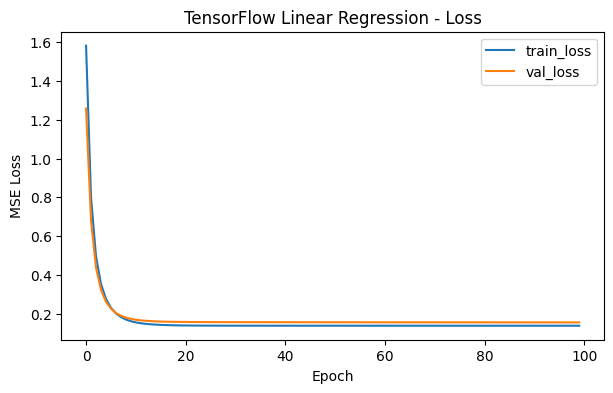

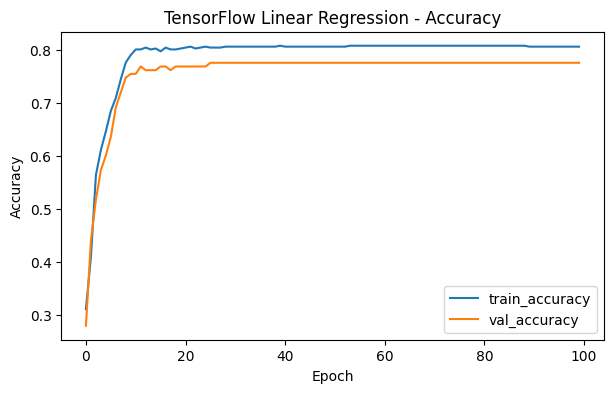

In [ ]:
# Cell 11: Biểu đồ loss và accuracy của TensorFlow

plt.plot(tf_history.history["loss"], label="train_loss")
plt.plot(tf_history.history["val_loss"], label="val_loss")
plt.title("TensorFlow Linear Regression - Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

plt.plot(tf_history.history["accuracy"], label="train_accuracy")
plt.plot(tf_history.history["val_accuracy"], label="val_accuracy")
plt.title("TensorFlow Linear Regression - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


CELL 12: Đánh giá mô hình TensorFlow trên test
Dùng mô hình TensorFlow để dự đoán trên tập test. Kết quả được đánh giá bằng MSE, MAE, R2, Accuracy, confusion matrix và classification report.

In [ ]:
# Cell 12: Đánh giá TensorFlow trên test một lần cuối

tf_pred_continuous = tf_model.predict(X_test_tf).reshape(-1)
tf_pred_class = (tf_pred_continuous >= 0.5).astype(int)

print("TensorFlow Test MSE:", mean_squared_error(y_test_tf, tf_pred_continuous))
print("TensorFlow Test MAE:", mean_absolute_error(y_test_tf, tf_pred_continuous))
print("TensorFlow Test R2:", r2_score(y_test_tf, tf_pred_continuous))
print("TensorFlow Test Accuracy:", accuracy_score(y_test_tf, tf_pred_class))

print("\nConfusion matrix:")
print(confusion_matrix(y_test_tf, tf_pred_class))

print("\nClassification report:")
print(classification_report(y_test_tf, tf_pred_class))


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
TensorFlow Test MSE: 0.15468069911003113
TensorFlow Test MAE: 0.30310583114624023
TensorFlow Test R2: 0.34701913595199585
TensorFlow Test Accuracy: 0.7988826815642458

Confusion matrix:
[[95 15]
 [21 48]]

Classification report:
              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84       110
         1.0       0.76      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



##CELL 13 Mô hình 2: Linear Regression bằng PyTorch

Phần này tự viết vòng lặp Gradient Descent để bạn thấy rõ:

1. Forward
2. Tính loss
3. Backward
4. Optimizer cập nhật trọng số
5. Lưu loss và accuracy theo từng epoch


In [ ]:
# Cell 13: Chuẩn bị dữ liệu cho PyTorch

X_train_torch = torch.tensor(X_train_processed, dtype=torch.float32)
X_val_torch = torch.tensor(X_val_processed, dtype=torch.float32)
X_test_torch = torch.tensor(X_test_processed, dtype=torch.float32)

y_train_torch = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
y_val_torch = torch.tensor(y_val.values.reshape(-1, 1), dtype=torch.float32)
y_test_torch = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32)

print(X_train_torch.shape, y_train_torch.shape)


torch.Size([569, 10]) torch.Size([569, 1])


CELL 14: Xây dựng mô hình Linear Regression bằng PyTorch
Định nghĩa class mô hình PyTorch gồm một lớp Linear. Sau đó khai báo MSELoss, optimizer SGD và hàm tính accuracy bằng cách ngưỡng hóa output tại 0.5.

In [ ]:
# Cell 14: Định nghĩa Linear Regression PyTorch

class LinearRegressionTorch(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

torch_model = LinearRegressionTorch(input_dim=X_train_torch.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(torch_model.parameters(), lr=0.01)

def binary_accuracy_from_linear_output(y_pred, y_true):
    y_class = (y_pred >= 0.5).float()
    return (y_class.eq(y_true).float().mean()).item()


CELL 15: Train PyTorch bằng vòng lặp Gradient Descent
viết quá trình train gồm forward, tính loss, backward và cập nhật trọng số. Sau mỗi epoch, chương trình lưu loss và accuracy của train và validation để vẽ biểu đồ.



In [ ]:
# Cell 15: Train PyTorch bằng Gradient Descent

epochs = 100
torch_train_losses = []
torch_val_losses = []
torch_train_accs = []
torch_val_accs = []

for epoch in range(epochs):
    # Train mode
    torch_model.train()

    # Forward
    train_pred = torch_model(X_train_torch)
    train_loss = criterion(train_pred, y_train_torch)

    # Backward
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Evaluation trên validation
    torch_model.eval()
    with torch.no_grad():
        val_pred = torch_model(X_val_torch)
        val_loss = criterion(val_pred, y_val_torch)

        train_acc = binary_accuracy_from_linear_output(train_pred, y_train_torch)
        val_acc = binary_accuracy_from_linear_output(val_pred, y_val_torch)

    torch_train_losses.append(train_loss.item())
    torch_val_losses.append(val_loss.item())
    torch_train_accs.append(train_acc)
    torch_val_accs.append(val_acc)

print("Train xong PyTorch")


Train xong PyTorch


CELL 16: Biểu đồ loss và accuracy của PyTorch
Vẽ biểu đồ loss và accuracy của mô hình PyTorch trên train và validation. Mục tiêu là quan sát quá trình học và so sánh độ ổn định của mô hình.

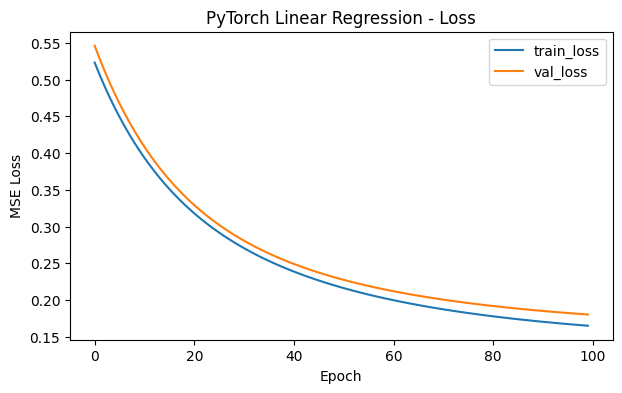

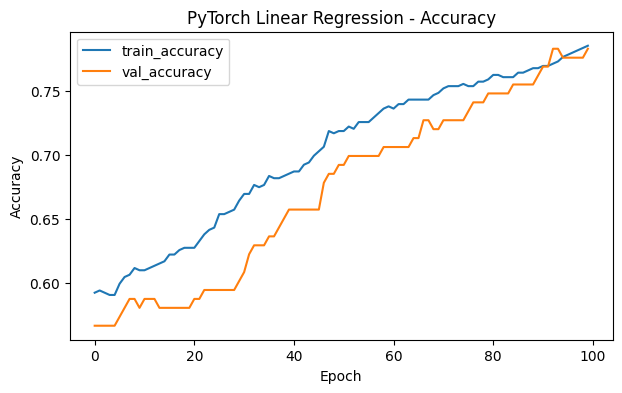

In [ ]:
# Cell 16: Biểu đồ loss và accuracy của PyTorch

plt.plot(torch_train_losses, label="train_loss")
plt.plot(torch_val_losses, label="val_loss")
plt.title("PyTorch Linear Regression - Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

plt.plot(torch_train_accs, label="train_accuracy")
plt.plot(torch_val_accs, label="val_accuracy")
plt.title("PyTorch Linear Regression - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


CELL 17: Đánh giá mô hình PyTorch trên test
dự đoán bằng mô hình PyTorch trên tập test và đánh giá kết quả bằng MSE, MAE, R2, Accuracy, confusion matrix và classification report.

In [ ]:
# Cell 17: Đánh giá PyTorch trên test một lần cuối

torch_model.eval()
with torch.no_grad():
    torch_pred_continuous = torch_model(X_test_torch).numpy().reshape(-1)

torch_pred_class = (torch_pred_continuous >= 0.5).astype(int)
y_test_np = y_test.values.astype(int)

print("PyTorch Test MSE:", mean_squared_error(y_test_np, torch_pred_continuous))
print("PyTorch Test MAE:", mean_absolute_error(y_test_np, torch_pred_continuous))
print("PyTorch Test R2:", r2_score(y_test_np, torch_pred_continuous))
print("PyTorch Test Accuracy:", accuracy_score(y_test_np, torch_pred_class))

print("\nConfusion matrix:")
print(confusion_matrix(y_test_np, torch_pred_class))

print("\nClassification report:")
print(classification_report(y_test_np, torch_pred_class))


PyTorch Test MSE: 0.18187807500362396
PyTorch Test MAE: 0.3549896776676178
PyTorch Test R2: 0.2322060465812683
PyTorch Test Accuracy: 0.776536312849162

Confusion matrix:
[[98 12]
 [28 41]]

Classification report:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       110
           1       0.77      0.59      0.67        69

    accuracy                           0.78       179
   macro avg       0.78      0.74      0.75       179
weighted avg       0.78      0.78      0.77       179



Cell 18: So sánh tổng hợp TensorFlow vs PyTorch trên Test Set

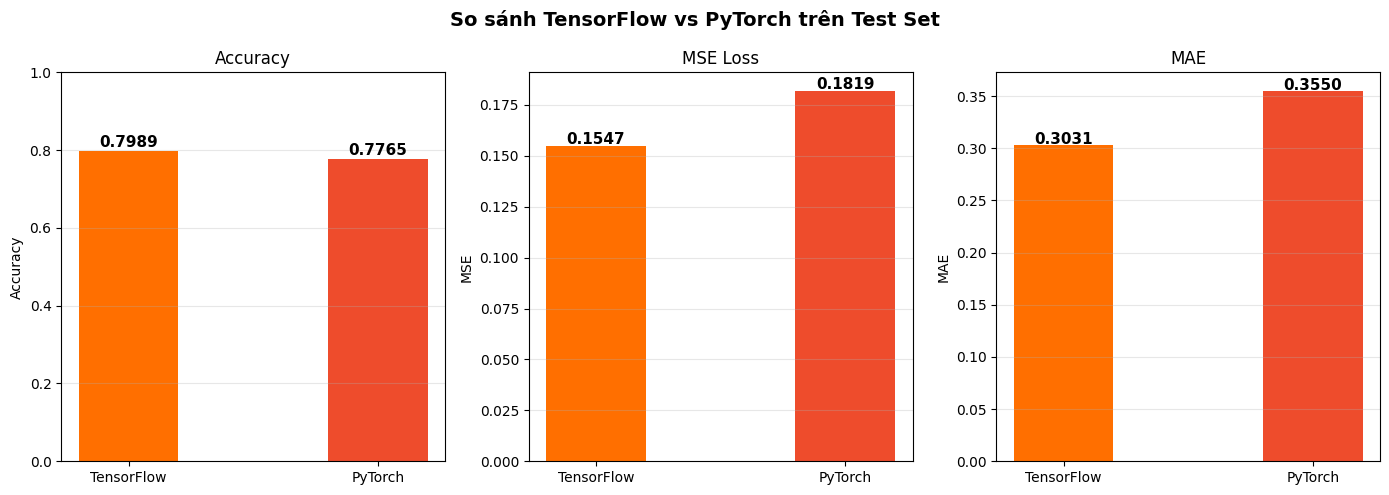


Metric           TensorFlow        PyTorch
Accuracy             0.7989         0.7765
MSE                  0.1547         0.1819
MAE                  0.3031         0.3550
R2 Score             0.3470         0.2322

Nhan xet:
  TensorFlow accuracy cao hon PyTorch: 0.7989 > 0.7765
  TensorFlow MSE thap hon (du doan sat hon): 0.1547 < 0.1819


In [18]:
# Cell 18: So sánh tổng hợp TensorFlow vs PyTorch trên Test Set

# --- Thu thập metrics ---
tf_acc   = accuracy_score(y_test_tf, tf_pred_class)
tf_mse   = mean_squared_error(y_test_tf, tf_pred_continuous)
tf_mae   = mean_absolute_error(y_test_tf, tf_pred_continuous)
tf_r2    = r2_score(y_test_tf, tf_pred_continuous)

pt_acc   = accuracy_score(y_test_np, torch_pred_class)
pt_mse   = mean_squared_error(y_test_np, torch_pred_continuous)
pt_mae   = mean_absolute_error(y_test_np, torch_pred_continuous)
pt_r2    = r2_score(y_test_np, torch_pred_continuous)

# --- Vẽ biểu đồ so sánh ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('So sánh TensorFlow vs PyTorch trên Test Set',
             fontsize=14, fontweight='bold')

frameworks = ['TensorFlow', 'PyTorch']
colors     = ['#FF6F00', '#EE4C2C']

# Biểu đồ 1: Accuracy
accs = [tf_acc, pt_acc]
bars = axes[0].bar(frameworks, accs, color=colors, width=0.4)
axes[0].set_title('Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 v + 0.01, f'{v:.4f}',
                 ha='center', fontweight='bold', fontsize=11)

# Biểu đồ 2: MSE Loss
mses = [tf_mse, pt_mse]
bars = axes[1].bar(frameworks, mses, color=colors, width=0.4)
axes[1].set_title('MSE Loss')
axes[1].set_ylabel('MSE')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, mses):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + 0.001, f'{v:.4f}',
                 ha='center', fontweight='bold', fontsize=11)

# Biểu đồ 3: MAE
maes = [tf_mae, pt_mae]
bars = axes[2].bar(frameworks, maes, color=colors, width=0.4)
axes[2].set_title('MAE')
axes[2].set_ylabel('MAE')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, maes):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 v + 0.001, f'{v:.4f}',
                 ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('comparison_tf_vs_pytorch.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Bảng tổng hợp ---
print("\n" + "=" * 45)
print(f"{'Metric':<12} {'TensorFlow':>14} {'PyTorch':>14}")
print("=" * 45)
print(f"{'Accuracy':<12} {tf_acc:>14.4f} {pt_acc:>14.4f}")
print(f"{'MSE':<12} {tf_mse:>14.4f} {pt_mse:>14.4f}")
print(f"{'MAE':<12} {tf_mae:>14.4f} {pt_mae:>14.4f}")
print(f"{'R2 Score':<12} {tf_r2:>14.4f} {pt_r2:>14.4f}")
print("=" * 45)

# --- Nhận xét tự động ---
print("\nNhan xet:")
if tf_acc > pt_acc:
    print(f"  TensorFlow accuracy cao hon PyTorch: {tf_acc:.4f} > {pt_acc:.4f}")
elif pt_acc > tf_acc:
    print(f"  PyTorch accuracy cao hon TensorFlow: {pt_acc:.4f} > {tf_acc:.4f}")
else:
    print(f"  Hai mo hinh co accuracy bang nhau: {tf_acc:.4f}")

if tf_mse < pt_mse:
    print(f"  TensorFlow MSE thap hon (du doan sat hon): {tf_mse:.4f} < {pt_mse:.4f}")
else:
    print(f"  PyTorch MSE thap hon (du doan sat hon): {pt_mse:.4f} < {tf_mse:.4f}")

## Ghi nhớ chống data leakage

Trong notebook này, các bước quan trọng là:

- `train_test_split` chạy trước preprocessing
- `preprocessor.fit_transform(X_train)` chỉ áp dụng với train
- `preprocessor.transform(X_val)` và `preprocessor.transform(X_test)` không fit lại
- Test set chỉ đánh giá ở cuối
- Không dùng `Survived` trong input
- Không fit scaler / encoder trên toàn bộ dataset


CELL 19: Test mô hình


   DỰ ĐOÁN KHẢ NĂNG SỐNG SÓT - TITANIC

Nhập thông tin hành khách:
Hạng vé Pclass (1 / 2 / 3): 3
Giới tính Sex (male / female): female
Tuổi Age (vd: 25): 20
Số anh chị em / vợ chồng SibSp (vd: 0): 1
Số bố mẹ / con cái Parch (vd: 0): 1
Giá vé Fare (vd: 50.0): 45
Cảng lên tàu Embarked (S / C / Q): Q

KẾT QUẢ DỰ ĐOÁN

Thông tin nhập vào:
  Pclass: 3 | Sex: female | Age: 20.0
  SibSp: 1 | Parch: 1 | Fare: 45.0 | Embarked: Q

TensorFlow:
  Xac suat song: 76.2%
  Du doan: SONG

PyTorch:
  Xac suat song: 84.2%
  Du doan: SONG



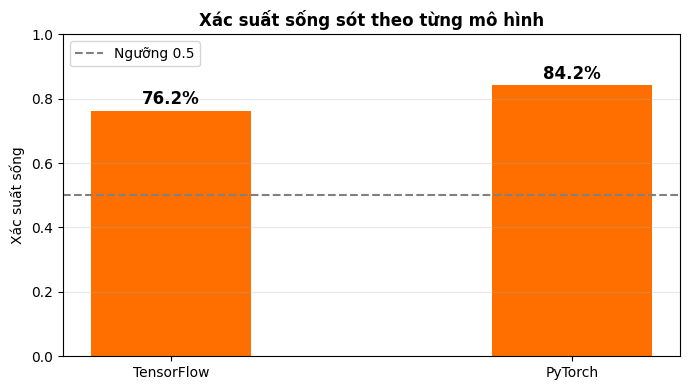

In [21]:
# Cell 19: Thử dự đoán với hành khách mới

print("=" * 50)
print("   DỰ ĐOÁN KHẢ NĂNG SỐNG SÓT - TITANIC")
print("=" * 50)

# --- Nhập thông tin hành khách ---
print("\nNhập thông tin hành khách:")

pclass   = int(input("Hạng vé Pclass (1 / 2 / 3): "))
sex      = input("Giới tính Sex (male / female): ").strip().lower()
age      = float(input("Tuổi Age (vd: 25): "))
sibsp    = int(input("Số anh chị em / vợ chồng SibSp (vd: 0): "))
parch    = int(input("Số bố mẹ / con cái Parch (vd: 0): "))
fare     = float(input("Giá vé Fare (vd: 50.0): "))
embarked = input("Cảng lên tàu Embarked (S / C / Q): ").strip().upper()

# --- Tạo DataFrame từ input ---
input_data = pd.DataFrame([{
    "Pclass"  : pclass,
    "Age"     : age,
    "SibSp"   : sibsp,
    "Parch"   : parch,
    "Fare"    : fare,
    "Sex"     : sex,
    "Embarked": embarked
}])

# --- Transform bằng preprocessor đã fit từ train (không fit lại) ---
input_processed = preprocessor.transform(input_data).astype("float32")

# --- Dự đoán bằng TensorFlow ---
tf_prob  = tf_model.predict(input_processed, verbose=0)[0][0]
tf_label = 1 if tf_prob >= 0.5 else 0

# --- Dự đoán bằng PyTorch ---
input_tensor = torch.tensor(input_processed, dtype=torch.float32)
torch_model.eval()
with torch.no_grad():
    pt_prob  = torch_model(input_tensor).item()
pt_label = 1 if pt_prob >= 0.5 else 0

# --- Hiển thị kết quả ---
print("\n" + "=" * 50)
print("KẾT QUẢ DỰ ĐOÁN")
print("=" * 50)

print(f"\nThông tin nhập vào:")
print(f"  Pclass: {pclass} | Sex: {sex} | Age: {age}")
print(f"  SibSp: {sibsp} | Parch: {parch} | Fare: {fare} | Embarked: {embarked}")

print(f"\nTensorFlow:")
print(f"  Xac suat song: {tf_prob*100:.1f}%")
print(f"  Du doan: {'SONG' if tf_label == 1 else 'MAT'}")

print(f"\nPyTorch:")
print(f"  Xac suat song: {pt_prob*100:.1f}%")
print(f"  Du doan: {'SONG' if pt_label == 1 else 'MAT'}")

print("\n" + "=" * 50)

# --- Biểu đồ xác suất ---
fig, ax = plt.subplots(figsize=(7, 4))
frameworks = ['TensorFlow', 'PyTorch']
probs      = [tf_prob, pt_prob]
colors     = ['#FF6F00' if p >= 0.5 else '#e74c3c' for p in probs]

bars = ax.bar(frameworks, probs, color=colors, width=0.4)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, label='Ngưỡng 0.5')
ax.set_title('Xác suất sống sót theo từng mô hình', fontweight='bold')
ax.set_ylabel('Xác suất sống')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for bar, p in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2,
            p + 0.02, f'{p*100:.1f}%',
            ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()